# Logistic Regresson With ROC curve and ROC AUC score

___ 
     We know that Logistic Regresson Threshold is 0.5 ( value > 0.5 becomes 1 and < 0.5 becomes 0) 

     SO How should be Come to a Conclusion to choose a specific threshold value ( domain Knowledge ) by default its 0.5

- see Nots to understand 
___

In [19]:
from sklearn.datasets import make_classification

In [20]:
X, y = make_classification(n_samples=1000, n_classes=2, random_state=42)

___
# Train Test SPlit
___

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42)

    create a  dummy model that will give for every value in y_test 0 probability

In [23]:
# generate a dummy model ( dummy model with default zero as output )
dumy_model_prob = [0 for _ in range(len(y_test))]  # store 0 for every value in y_test
dumy_model_prob

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

___
# Model Training 
___

In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [26]:
# prediction Based on probability

model_prb =  model.predict_proba(X_test)

In [27]:
model_prb # we get two values one is for negative and one is for positive 

array([[4.19931091e-01, 5.80068909e-01],
       [1.40969604e-01, 8.59030396e-01],
       [5.08532523e-01, 4.91467477e-01],
       [1.31791655e-01, 8.68208345e-01],
       [5.21703453e-02, 9.47829655e-01],
       [9.39186107e-01, 6.08138932e-02],
       [7.78171117e-01, 2.21828883e-01],
       [1.88561984e-01, 8.11438016e-01],
       [2.55292019e-01, 7.44707981e-01],
       [6.62765922e-01, 3.37234078e-01],
       [5.01950468e-02, 9.49804953e-01],
       [4.41292340e-01, 5.58707660e-01],
       [9.95620384e-01, 4.37961605e-03],
       [5.44238440e-01, 4.55761560e-01],
       [2.58896799e-01, 7.41103201e-01],
       [8.14685260e-01, 1.85314740e-01],
       [9.40297613e-01, 5.97023874e-02],
       [5.33894329e-02, 9.46610567e-01],
       [1.29962431e-01, 8.70037569e-01],
       [5.14898680e-01, 4.85101320e-01],
       [7.59611431e-03, 9.92403886e-01],
       [7.78460309e-01, 2.21539691e-01],
       [9.49118219e-01, 5.08817814e-02],
       [9.08234080e-01, 9.17659197e-02],
       [3.664788

In [28]:
model_prb = model_prb[:,1]
# focus on positive outcome

___
# ROC Curve and ROC AUC
___

In [29]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [30]:
# Calculate the scores 
dumy_model_auc = roc_auc_score(y_test, dumy_model_prob)  # calculate for dummy model
 
model_auc = roc_auc_score(y_test, model_prb) # calculate for logiestic model 

print("Dummy Model  : ", dumy_model_auc)  # calculate model accuracy 
print("Model : ", model_auc)





Dummy Model  :  0.5
Model :  0.9244444444444444


# False Positive Rate (FPR) & True Positive Rate (TPR)

---

## Confusion Matrix (Quick Reference)

|  | Actual Positive | Actual  Negative |
|---|---|---|
| **predicted Positive** | TP (True Positive) | FP ( Faslse Positive) |
| **Predicted Negative** | FN (False Negative)| TN (True Negative) |

---

## True Positive Rate (TPR)

**Also called:** Sensitivity, Recall, Hit Rate

### Formula

$$TPR = \frac{TP}{TP + FN}$$

### What it means

Out of **all actual positives**, how many did the model **correctly catch**?

### Example

- 100 actual fire events in your Forest Fire dataset
- Model correctly predicted 80 of them → **TPR = 80/100 = 0.80**

### Key Point

> High TPR = model is **good at catching real positives** (few misses).

---

## False Positive Rate (FPR)

**Also called:** Fall-out, Type I Error Rate

### Formula

$$FPR = \frac{FP}{FP + TN}$$

### What it means

Out of **all actual negatives**, how many did the model **wrongly flag as positive**?

### Example

- 200 actual non-fire days
- Model incorrectly predicted 40 of them as fire → **FPR = 40/200 = 0.20**

### Key Point

> High FPR = model raises **too many false alarms**.

---

## Side-by-Side Comparison

| | TPR | FPR |
|---|---|---|
| **Full name** | True Positive Rate | False Positive Rate |
| **Numerator** | TP | FP |
| **Denominator** | TP + FN (all actual positives) | FP + TN (all actual negatives) |
| **Ideal value** | 1.0 (higher is better) | 0.0 (lower is better) |
| **Also known as** | Sensitivity / Recall | Fall-out / Type I Error Rate |
| **Question answered** | "Did we catch real cases?" | "How often did we cry wolf?" |

---

## ROC Curve Connection

The **ROC curve** plots **TPR (y-axis) vs FPR (x-axis)** across all thresholds.

- Top-left corner = perfect model (TPR=1, FPR=0)
- Diagonal line = random guessing
- **AUC** (Area Under Curve) summarizes overall performance — closer to 1.0 is better

---

## Memory Trick

| Rate | Denominator | Think... |
|---|---|---|
| TPR | All **actual positives** | "Of the real ones, how many did we get?" |
| FPR | All **actual negatives** | "Of the safe ones, how many did we wrongly alarm?" |

In [37]:
dumy_FPR , dumy_TPR, _ = roc_curve(y_test, dumy_model_prob)

model_FPR, model_TPR, threshold = roc_curve(y_test, model_prb)

# roc_curve() returns

    FPR → False Positive Rate
    TPR → True Positive Rate
    thresholds → Probability thresholds used to compute the curve

```python 
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    # but above we wrote 

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
```
### The underscore (_) means: 
    "I don't need this returned value."


In [39]:
model_FPR,  model_TPR

(array([0.        , 0.        , 0.        , 0.00869565, 0.00869565,
        0.0173913 , 0.0173913 , 0.02608696, 0.02608696, 0.03478261,
        0.03478261, 0.04347826, 0.04347826, 0.05217391, 0.05217391,
        0.06956522, 0.06956522, 0.07826087, 0.07826087, 0.08695652,
        0.08695652, 0.09565217, 0.09565217, 0.10434783, 0.10434783,
        0.11304348, 0.11304348, 0.12173913, 0.12173913, 0.13043478,
        0.13043478, 0.13913043, 0.13913043, 0.14782609, 0.14782609,
        0.16521739, 0.16521739, 0.17391304, 0.17391304, 0.2173913 ,
        0.2173913 , 0.23478261, 0.23478261, 0.31304348, 0.31304348,
        0.33043478, 0.33043478, 0.35652174, 0.35652174, 0.4173913 ,
        0.4173913 , 0.43478261, 0.43478261, 0.50434783, 0.50434783,
        0.53043478, 0.53043478, 0.74782609, 0.74782609, 0.93043478,
        0.93043478, 1.        ]),
 array([0.        , 0.00740741, 0.46666667, 0.46666667, 0.51111111,
        0.51111111, 0.53333333, 0.53333333, 0.54074074, 0.54074074,
        0.5481

In [35]:
import matplotlib.pyplot as plt 

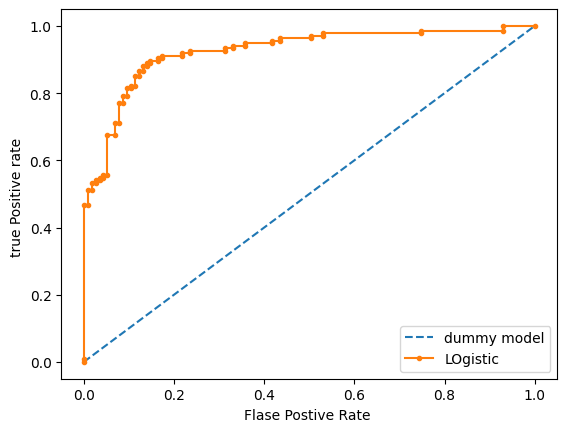

In [40]:
plt.plot(dumy_FPR ,dumy_TPR, linestyle = '--', label = "dummy model")
plt.plot(model_FPR, model_TPR,marker = '.' , label = "LOgistic" )

plt.xlabel("Flase Postive Rate ")
plt.ylabel("true Positive rate ")

plt.legend()
plt.show()

# this is ROC AUC Cuve 

# Area uder the curve of logistic is more means it performed well

# How to choose Threshold 

### Aim : Slecet Threshold which gives HIgh TPR and Low FPR

    Obser on the x-axis we have FPR and y-axis we have TPR 

    if domain expert tell us that FPR range is till 0.2 .. so on axis we will move farther than 0.2 and see on y-axis at which point we get high TPR and LOW FPR

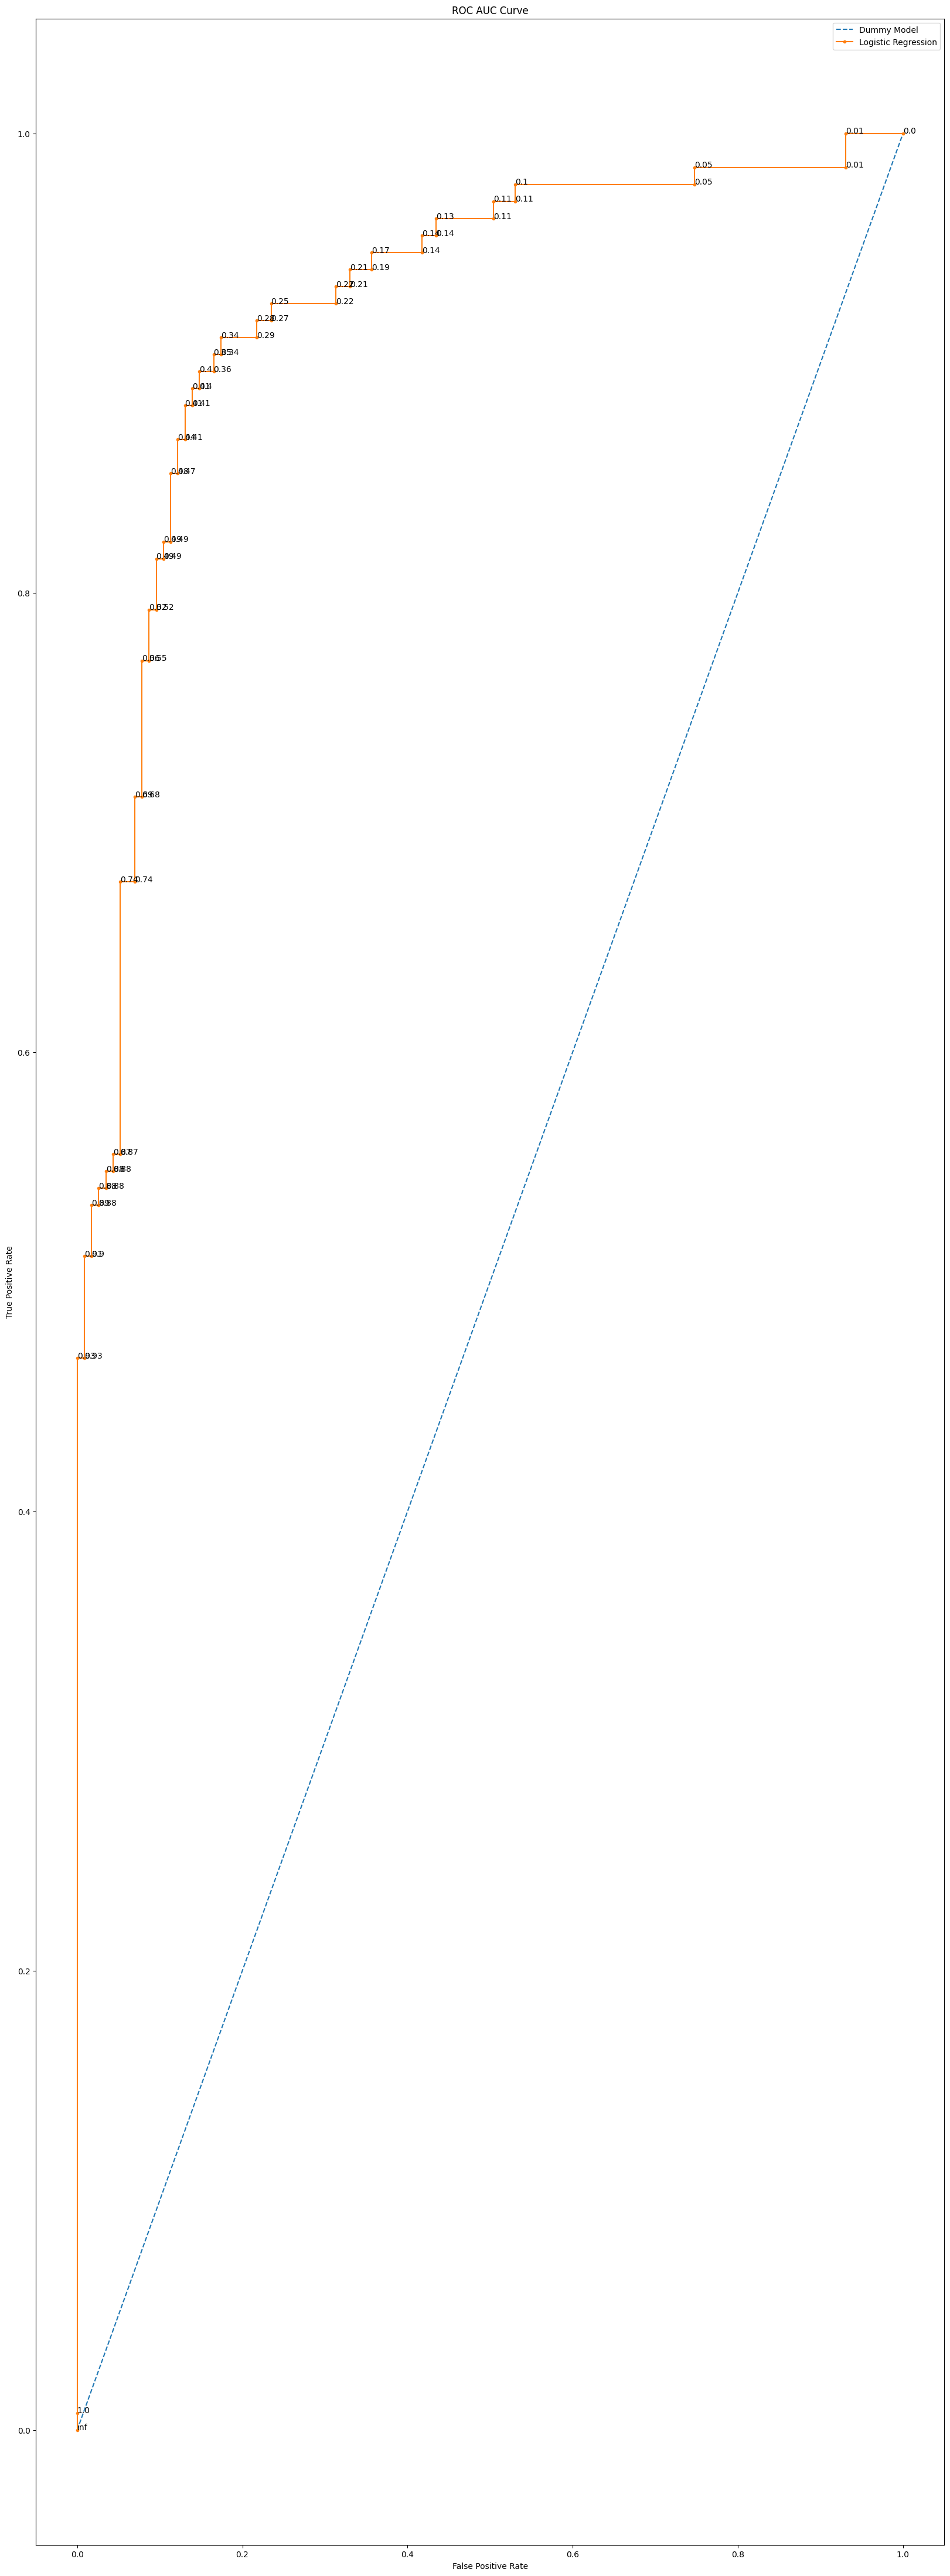

In [51]:
import numpy as np 
fig, ax = plt.subplots(figsize=(20, 56))  # create figure AND axes together

ax.plot(dumy_FPR, dumy_TPR, linestyle='--', label="Dummy Model")
ax.plot(model_FPR, model_TPR, marker='.', label="Logistic Regression")

# annotate thresholds
for xyz in zip(model_FPR, model_TPR, threshold):
    ax.annotate('%s' % np.round(xyz[2], 2), xy=(xyz[0], xyz[1]))

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC AUC Curve")
ax.legend()

plt.show()# this is ROC AUC Cuve 

# Area uder the curve of logistic is more means it performed well




# ax.annotate(
#     text,
#     xy=(x, y)
# )